In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mticker
import numpy as np

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='Blues_d')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [2]:
# Cargar los datos
rentabilidad = pd.read_excel(
    'CMF_CONT_RENTAB_STO_RAZ_PORC_MONT_V_20260331053935.xlsx',
    sheet_name='Cuadro',
    skiprows=3
)

eficiencia = pd.read_excel(
    'CMF_CONT_EFICOPER_STO_RAZ_PORC_MONT_V_20260331053935.xlsx',
    sheet_name='Cuadro',
    skiprows=3
)

print("Rentabilidad — forma:", rentabilidad.shape)
print("Eficiencia — forma:", eficiencia.shape)
print("\nPrimeras filas rentabilidad:")
rentabilidad.head()

Rentabilidad — forma: (218, 9)
Eficiencia — forma: (218, 4)

Primeras filas rentabilidad:


,Fecha,Rentabilidad sobre patrimonio antes de impuestos,Rentabilidad sobre activos totales antes de impuestos,Rentabilidad sobre patrimonio promedio antes de impuestos,Rentabilidad sobre activos promedio antes de impuestos,Rentabilidad sobre patrimonio después de impuestos,Rentabilidad sobre activos totales después de impuestos,Rentabilidad sobre patrimonio promedio después de impuestos,Rentabilidad sobre activos promedio después de impuestos
0,2008-01-01,21.941970,1.673332,-,-,16.660475,1.270556,-,-
1,2008-02-01,20.361026,1.541187,-,-,15.738109,1.191265,-,-
2,2008-03-01,18.657124,1.390262,-,-,14.606346,1.088413,-,-
3,2008-04-01,18.723055,1.370863,-,-,14.779083,1.082094,-,-
4,2008-05-01,18.560176,1.376689,-,-,14.705628,1.090780,-,-


In [3]:
# Renombrar columnas para trabajar más fácil
rentabilidad.columns = [
    'fecha',
    'roe_antes_imp',
    'roa_antes_imp', 
    'roe_prom_antes_imp',
    'roa_prom_antes_imp',
    'roe_despues_imp',
    'roa_despues_imp',
    'roe_prom_despues_imp',
    'roa_prom_despues_imp'
]

eficiencia.columns = [
    'fecha',
    'gasto_sobre_activos',
    'gasto_sobre_ingresos',
    'perdidas_sobre_ingresos'
]

# Convertir fecha a formato datetime
rentabilidad['fecha'] = pd.to_datetime(rentabilidad['fecha'])
eficiencia['fecha'] = pd.to_datetime(eficiencia['fecha'])

# Reemplazar guiones por NaN (valor nulo real de pandas)
rentabilidad = rentabilidad.replace('-', pd.NA)
eficiencia = eficiencia.replace('-', pd.NA)

# Convertir columnas numéricas al tipo correcto
cols_rent = rentabilidad.columns[1:]
cols_efic = eficiencia.columns[1:]

rentabilidad[cols_rent] = rentabilidad[cols_rent].apply(pd.to_numeric, errors='coerce')
eficiencia[cols_efic] = eficiencia[cols_efic].apply(pd.to_numeric, errors='coerce')

# Filtrar desde 2019 para análisis principal
rent_reciente = rentabilidad[rentabilidad['fecha'] >= '2019-01-01'].copy()
efic_reciente = eficiencia[eficiencia['fecha'] >= '2019-01-01'].copy()

print(f"Datos completos: {len(rentabilidad)} meses ({rentabilidad['fecha'].min().year}–{rentabilidad['fecha'].max().year})")
print(f"Datos análisis principal: {len(rent_reciente)} meses")
print(f"\nValores nulos en rentabilidad:\n{rent_reciente.isnull().sum()}")

Datos completos: 218 meses (2008–2026)
Datos análisis principal: 86 meses

Valores nulos en rentabilidad:
fecha                   0
roe_antes_imp           0
roa_antes_imp           0
roe_prom_antes_imp      0
roa_prom_antes_imp      0
roe_despues_imp         0
roa_despues_imp         0
roe_prom_despues_imp    0
roa_prom_despues_imp    0
dtype: int64


In [4]:
# Estadísticas descriptivas del período reciente
print("=" * 55)
print("ESTADÍSTICAS SISTEMA BANCARIO CHILENO 2019-2026")
print("=" * 55)

print("\n📊 RENTABILIDAD (ROE y ROA después de impuestos):")
print(rent_reciente[['roe_despues_imp', 'roa_despues_imp']].describe().round(2))

print("\n⚙️ EFICIENCIA OPERATIVA:")
print(efic_reciente[['gasto_sobre_ingresos', 'gasto_sobre_activos']].describe().round(2))

# Identificar el peor y mejor mes por ROE
mejor_mes = rent_reciente.loc[rent_reciente['roe_despues_imp'].idxmax()]
peor_mes = rent_reciente.loc[rent_reciente['roe_despues_imp'].idxmin()]

print(f"\n🔼 Mejor ROE: {mejor_mes['roe_despues_imp']:.2f}% — {mejor_mes['fecha'].strftime('%b %Y')}")
print(f"🔽 Peor ROE:  {peor_mes['roe_despues_imp']:.2f}% — {peor_mes['fecha'].strftime('%b %Y')}")

ESTADÍSTICAS SISTEMA BANCARIO CHILENO 2019-2026

📊 RENTABILIDAD (ROE y ROA después de impuestos):
       roe_despues_imp  roa_despues_imp
count            86.00            86.00
mean             14.59             1.11
std               4.23             0.31
min               2.95             0.19
25%              12.96             1.02
50%              15.01             1.13
75%              16.13             1.31
max              23.38             1.62

⚙️ EFICIENCIA OPERATIVA:
       gasto_sobre_ingresos  gasto_sobre_activos
count                 86.00                86.00
mean                  45.79                 1.86
std                    4.46                 0.17
min                   38.59                 1.59
25%                   43.38                 1.70
50%                   44.64                 1.88
75%                   48.00                 1.96
max                   58.74                 2.24

🔼 Mejor ROE: 23.38% — Jun 2022
🔽 Peor ROE:  2.95% — Jun 2020


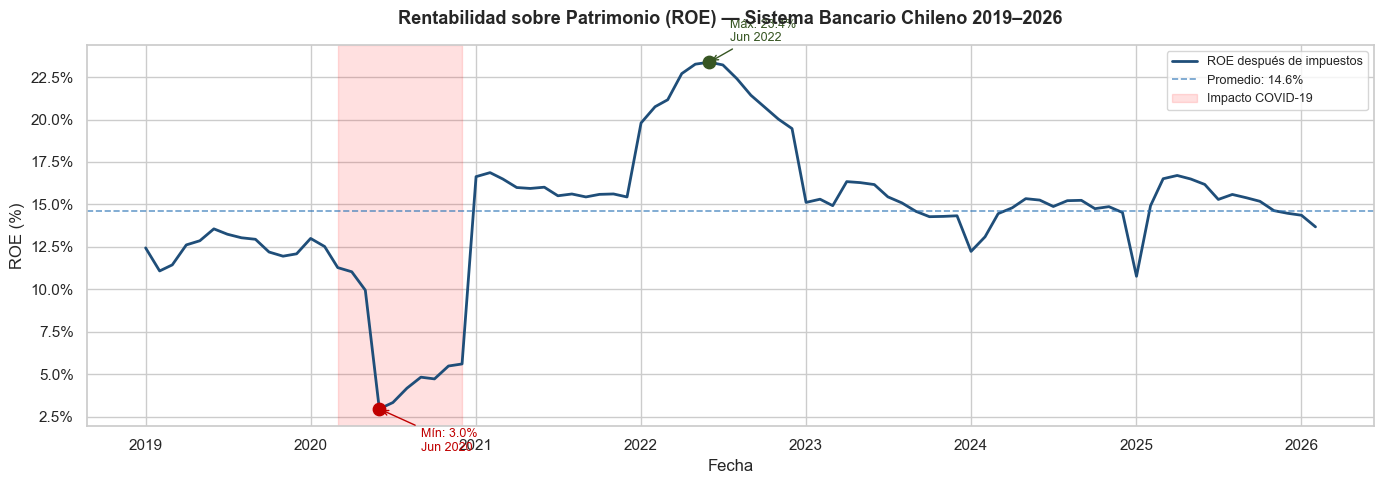

Gráfico guardado como grafico_roe.png ✓


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

# Línea principal ROE
ax.plot(rent_reciente['fecha'], 
        rent_reciente['roe_despues_imp'],
        color='#1F4E79', linewidth=2, label='ROE después de impuestos')

# Línea de promedio histórico
promedio_roe = rent_reciente['roe_despues_imp'].mean()
ax.axhline(y=promedio_roe, color='#2E75B6', linestyle='--', 
           linewidth=1.2, alpha=0.7, label=f'Promedio: {promedio_roe:.1f}%')

# Marcar el peor y mejor mes
ax.scatter(peor_mes['fecha'], peor_mes['roe_despues_imp'], 
           color='#C00000', s=80, zorder=5)
ax.annotate(f"Mín: {peor_mes['roe_despues_imp']:.1f}%\n{peor_mes['fecha'].strftime('%b %Y')}",
            xy=(peor_mes['fecha'], peor_mes['roe_despues_imp']),
            xytext=(30, -30), textcoords='offset points',
            fontsize=9, color='#C00000',
            arrowprops=dict(arrowstyle='->', color='#C00000'))

ax.scatter(mejor_mes['fecha'], mejor_mes['roe_despues_imp'], 
           color='#375623', s=80, zorder=5)
ax.annotate(f"Máx: {mejor_mes['roe_despues_imp']:.1f}%\n{mejor_mes['fecha'].strftime('%b %Y')}",
            xy=(mejor_mes['fecha'], mejor_mes['roe_despues_imp']),
            xytext=(15, 15), textcoords='offset points',
            fontsize=9, color='#375623',
            arrowprops=dict(arrowstyle='->', color='#375623'))

# Sombrear período COVID
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
           alpha=0.12, color='red', label='Impacto COVID-19')

ax.set_title('Rentabilidad sobre Patrimonio (ROE) — Sistema Bancario Chileno 2019–2026',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Fecha')
ax.set_ylabel('ROE (%)')
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig('grafico_roe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como grafico_roe.png ✓")

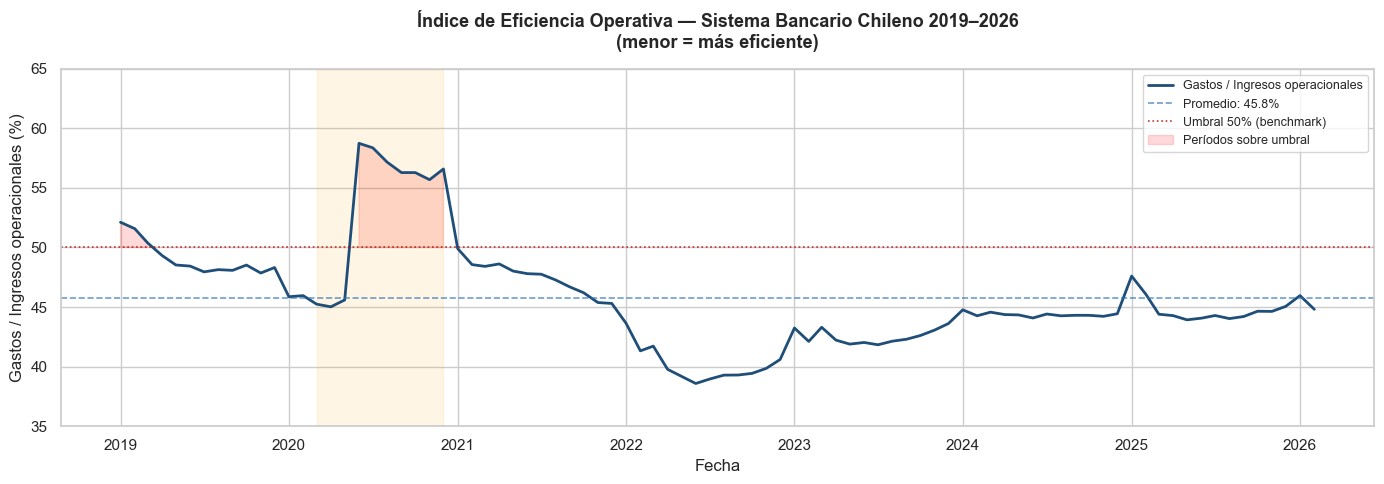

Gráfico guardado ✓


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(efic_reciente['fecha'],
        efic_reciente['gasto_sobre_ingresos'],
        color='#1F4E79', linewidth=2, label='Gastos / Ingresos operacionales')

promedio_efic = efic_reciente['gasto_sobre_ingresos'].mean()
ax.axhline(y=promedio_efic, color='#2E75B6', linestyle='--',
           linewidth=1.2, alpha=0.7, label=f'Promedio: {promedio_efic:.1f}%')

# Umbral de eficiencia referencial (50% es el benchmark internacional)
ax.axhline(y=50, color='#C00000', linestyle=':', 
           linewidth=1.2, alpha=0.8, label='Umbral 50% (benchmark)')

# Sombrear períodos sobre el umbral (ineficiencia)
ax.fill_between(efic_reciente['fecha'],
                efic_reciente['gasto_sobre_ingresos'],
                50,
                where=(efic_reciente['gasto_sobre_ingresos'] > 50),
                alpha=0.15, color='red', label='Períodos sobre umbral')

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
           alpha=0.10, color='orange')

ax.set_title('Índice de Eficiencia Operativa — Sistema Bancario Chileno 2019–2026\n'
             '(menor = más eficiente)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Fecha')
ax.set_ylabel('Gastos / Ingresos operacionales (%)')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(35, 65)
plt.tight_layout()
plt.savefig('grafico_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado ✓")

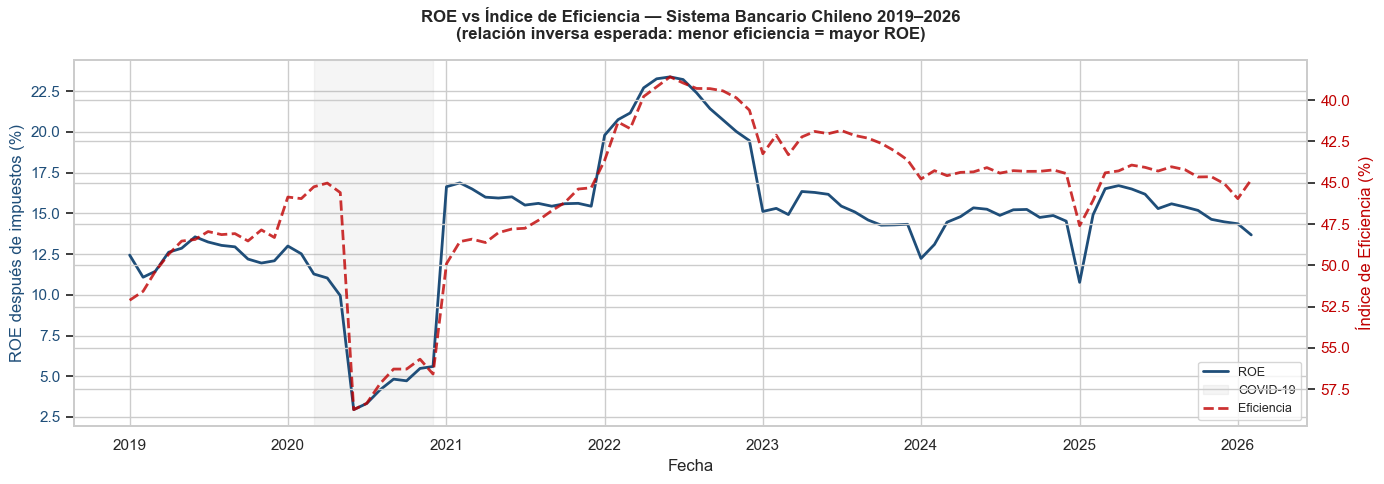

Gráfico guardado ✓


In [7]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Eje izquierdo — ROE
color_roe = '#1F4E79'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('ROE después de impuestos (%)', color=color_roe)
ax1.plot(rent_reciente['fecha'], rent_reciente['roe_despues_imp'],
         color=color_roe, linewidth=2, label='ROE')
ax1.tick_params(axis='y', labelcolor=color_roe)

# Eje derecho — Eficiencia (eje secundario)
ax2 = ax1.twinx()
color_efic = '#C00000'
ax2.set_ylabel('Índice de Eficiencia (%)', color=color_efic)
ax2.plot(efic_reciente['fecha'], efic_reciente['gasto_sobre_ingresos'],
         color=color_efic, linewidth=2, linestyle='--', label='Eficiencia', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_efic)
ax2.invert_yaxis()  # Invertir: menor eficiencia = arriba (peor)

# Sombrear COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
            alpha=0.08, color='gray', label='COVID-19')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

ax1.set_title('ROE vs Índice de Eficiencia — Sistema Bancario Chileno 2019–2026\n'
              '(relación inversa esperada: menor eficiencia = mayor ROE)',
              fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('grafico_roe_vs_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado ✓")

MATRIZ DE CORRELACIÓN:
                      roe_despues_imp  roa_despues_imp  gasto_sobre_ingresos  \
roe_despues_imp                 1.000            0.924                -0.870   
roa_despues_imp                 0.924            1.000                -0.846   
gasto_sobre_ingresos           -0.870           -0.846                 1.000   
gasto_sobre_activos            -0.632           -0.401                 0.722   

                      gasto_sobre_activos  
roe_despues_imp                    -0.632  
roa_despues_imp                    -0.401  
gasto_sobre_ingresos                0.722  
gasto_sobre_activos                 1.000  

Correlación ROE vs Índice de Eficiencia: -0.870
→ Correlación negativa fuerte: cuando los gastos suben, la rentabilidad baja


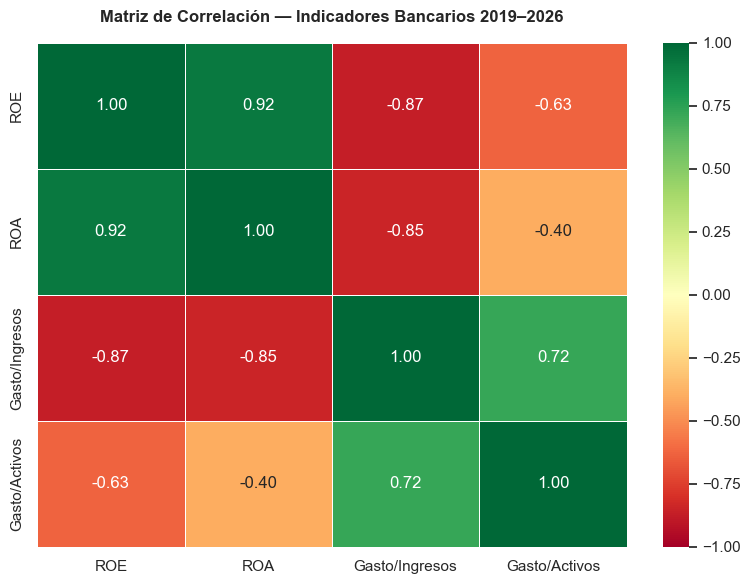

Gráfico guardado ✓


In [8]:
# Unir ambos dataframes por fecha para correlación
df_combinado = pd.merge(
    rent_reciente[['fecha', 'roe_despues_imp', 'roa_despues_imp']],
    efic_reciente[['fecha', 'gasto_sobre_ingresos', 'gasto_sobre_activos']],
    on='fecha'
)

# Calcular correlación
correlacion = df_combinado[['roe_despues_imp', 'roa_despues_imp', 
                             'gasto_sobre_ingresos', 'gasto_sobre_activos']].corr()

print("MATRIZ DE CORRELACIÓN:")
print(correlacion.round(3))

# Correlación específica ROE vs Eficiencia
corr_roe_efic = df_combinado['roe_despues_imp'].corr(df_combinado['gasto_sobre_ingresos'])
print(f"\nCorrelación ROE vs Índice de Eficiencia: {corr_roe_efic:.3f}")

if corr_roe_efic < -0.5:
    print("→ Correlación negativa fuerte: cuando los gastos suben, la rentabilidad baja")
elif corr_roe_efic < -0.3:
    print("→ Correlación negativa moderada")
else:
    print("→ Correlación débil o no significativa")

# Heatmap de correlación
fig, ax = plt.subplots(figsize=(8, 6))
mascara = [[False, False, False, False],
           [False, False, False, False],
           [False, False, False, False],
           [False, False, False, False]]

sns.heatmap(correlacion, 
            annot=True, fmt='.2f', 
            cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            xticklabels=['ROE', 'ROA', 'Gasto/Ingresos', 'Gasto/Activos'],
            yticklabels=['ROE', 'ROA', 'Gasto/Ingresos', 'Gasto/Activos'])

ax.set_title('Matriz de Correlación — Indicadores Bancarios 2019–2026',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('grafico_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado ✓")

In [9]:
# Definir períodos de análisis
periodos = {
    'Pre-COVID (2019)':     ('2019-01-01', '2020-02-28'),
    'COVID (2020-2021)':    ('2020-03-01', '2021-12-31'),
    'Boom post-COVID (2022)': ('2022-01-01', '2022-12-31'),
    'Normalización (2023-2026)': ('2023-01-01', '2026-12-31')
}

print("=" * 70)
print("ANÁLISIS POR PERÍODOS — SISTEMA BANCARIO CHILENO")
print("=" * 70)
print(f"{'Período':<30} {'ROE prom':>10} {'ROE min':>10} {'ROE max':>10} {'Efic prom':>10}")
print("-" * 70)

resumen = []
for nombre, (inicio, fin) in periodos.items():
    r = rent_reciente[
        (rent_reciente['fecha'] >= inicio) & 
        (rent_reciente['fecha'] <= fin)
    ]
    e = efic_reciente[
        (efic_reciente['fecha'] >= inicio) & 
        (efic_reciente['fecha'] <= fin)
    ]
    
    if len(r) > 0:
        roe_prom = r['roe_despues_imp'].mean()
        roe_min  = r['roe_despues_imp'].min()
        roe_max  = r['roe_despues_imp'].max()
        efic_prom = e['gasto_sobre_ingresos'].mean()
        
        print(f"{nombre:<30} {roe_prom:>9.1f}% {roe_min:>9.1f}% {roe_max:>9.1f}% {efic_prom:>9.1f}%")
        resumen.append({
            'periodo': nombre,
            'roe_promedio': round(roe_prom, 2),
            'eficiencia_promedio': round(efic_prom, 2)
        })

print("=" * 70)

# Hallazgos clave
print("\n📌 HALLAZGOS PRINCIPALES:")
print(f"  1. Correlación ROE vs Eficiencia: {corr_roe_efic:.3f} (negativa fuerte)")
print(f"  2. Peor período: COVID — ROE cayó a {rent_reciente['roe_despues_imp'].min():.1f}%")
print(f"  3. Mejor período: Post-COVID 2022 — ROE alcanzó {rent_reciente['roe_despues_imp'].max():.1f}%")
print(f"  4. Eficiencia promedio 2019-2026: {efic_reciente['gasto_sobre_ingresos'].mean():.1f}%")
print(f"  5. Sistema bancario bajo benchmark 50% en {(efic_reciente['gasto_sobre_ingresos'] < 50).sum()} de {len(efic_reciente)} meses")

# Exportar resumen a Excel
df_resumen = pd.DataFrame(resumen)
df_resumen.to_excel('resumen_analisis.xlsx', index=False)
print("\n✓ Resumen exportado a resumen_analisis.xlsx")

ANÁLISIS POR PERÍODOS — SISTEMA BANCARIO CHILENO
Período                          ROE prom    ROE min    ROE max  Efic prom
----------------------------------------------------------------------
Pre-COVID (2019)                    12.5%      11.1%      13.6%      48.6%
COVID (2020-2021)                   11.6%       3.0%      16.9%      50.2%
Boom post-COVID (2022)              21.5%      19.5%      23.4%      40.1%
Normalización (2023-2026)           14.9%      10.8%      16.7%      44.0%

📌 HALLAZGOS PRINCIPALES:
  1. Correlación ROE vs Eficiencia: -0.870 (negativa fuerte)
  2. Peor período: COVID — ROE cayó a 3.0%
  3. Mejor período: Post-COVID 2022 — ROE alcanzó 23.4%
  4. Eficiencia promedio 2019-2026: 45.8%
  5. Sistema bancario bajo benchmark 50% en 76 de 86 meses

✓ Resumen exportado a resumen_analisis.xlsx


TENDENCIA RECIENTE — ÚLTIMOS 12 MESES
ROE promedio: 15.3%
Eficiencia promedio: 44.6%
Tendencia ROE: ↓ Deteriorando
Tendencia eficiencia: ✓ Mejorando (bajando)


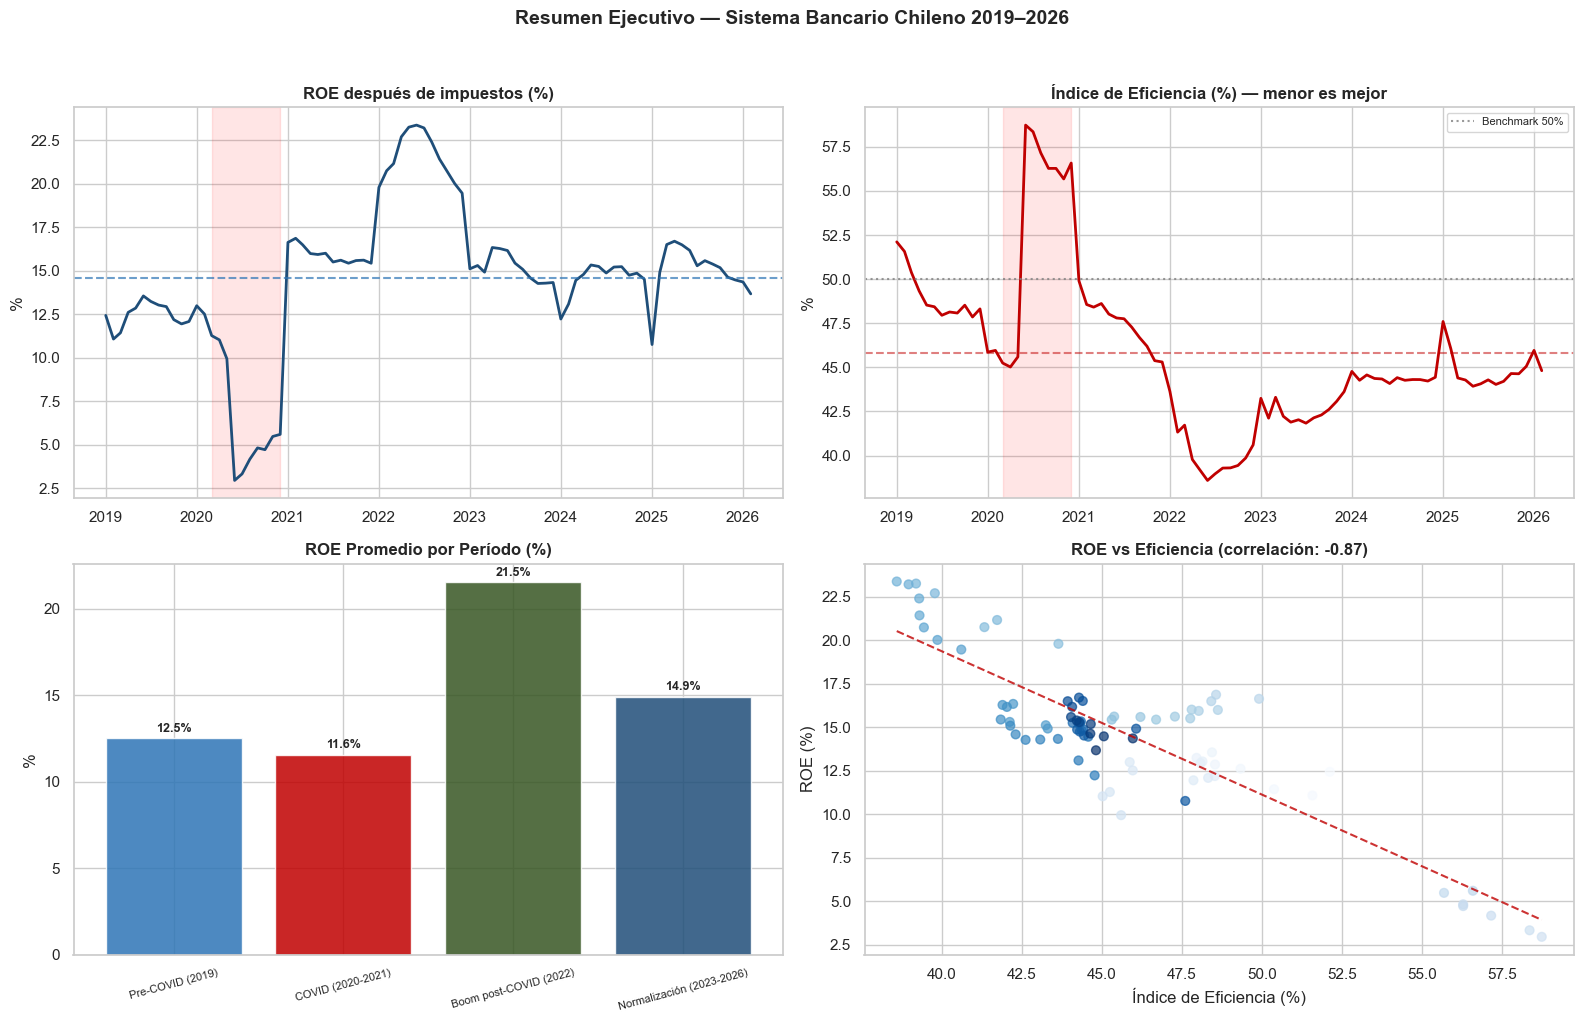

Dashboard final guardado ✓


In [12]:
# Análisis del período más reciente (últimos 12 meses)
ultimos_12 = rent_reciente[
    rent_reciente['fecha'] >= rent_reciente['fecha'].max() - pd.DateOffset(months=12)
].copy()

ultimos_12_efic = efic_reciente[
    efic_reciente['fecha'] >= efic_reciente['fecha'].max() - pd.DateOffset(months=12)
].copy()

print("TENDENCIA RECIENTE — ÚLTIMOS 12 MESES")
print(f"ROE promedio: {ultimos_12['roe_despues_imp'].mean():.1f}%")
print(f"Eficiencia promedio: {ultimos_12_efic['gasto_sobre_ingresos'].mean():.1f}%")
print(f"Tendencia ROE: {'↑ Mejorando' if ultimos_12['roe_despues_imp'].iloc[-1] > ultimos_12['roe_despues_imp'].iloc[0] else '↓ Deteriorando'}")
print(f"Tendencia eficiencia: {'✓ Mejorando (bajando)' if ultimos_12_efic['gasto_sobre_ingresos'].iloc[-1] < ultimos_12_efic['gasto_sobre_ingresos'].iloc[0] else '⚠ Deteriorando (subiendo)'}")

# Gráfico final — Resumen ejecutivo con 4 paneles
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Resumen Ejecutivo — Sistema Bancario Chileno 2019–2026', 
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1 — ROE histórico
ax1 = axes[0, 0]
ax1.plot(rent_reciente['fecha'], rent_reciente['roe_despues_imp'], 
         color='#1F4E79', linewidth=2)
ax1.axhline(y=rent_reciente['roe_despues_imp'].mean(), 
            color='#2E75B6', linestyle='--', alpha=0.7)
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'), 
            alpha=0.1, color='red')
ax1.set_title('ROE después de impuestos (%)', fontweight='bold')
ax1.set_ylabel('%')

# Panel 2 — Eficiencia histórica
ax2 = axes[0, 1]
ax2.plot(efic_reciente['fecha'], efic_reciente['gasto_sobre_ingresos'],
         color='#C00000', linewidth=2)
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.8, label='Benchmark 50%')
ax2.axhline(y=efic_reciente['gasto_sobre_ingresos'].mean(),
            color='#C00000', linestyle='--', alpha=0.5)
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
            alpha=0.1, color='red')
ax2.set_title('Índice de Eficiencia (%) — menor es mejor', fontweight='bold')
ax2.set_ylabel('%')
ax2.legend(fontsize=8)

# Panel 3 — ROE por período (barras)
ax3 = axes[1, 0]
df_res = pd.DataFrame(resumen)
colores = ['#2E75B6', '#C00000', '#375623', '#1F4E79']
bars = ax3.bar(df_res['periodo'], df_res['roe_promedio'], 
               color=colores, alpha=0.85, edgecolor='white')
ax3.set_title('ROE Promedio por Período (%)', fontweight='bold')
ax3.set_ylabel('%')
ax3.tick_params(axis='x', rotation=15, labelsize=8)
for bar, val in zip(bars, df_res['roe_promedio']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4 — Scatter ROE vs Eficiencia
ax4 = axes[1, 1]
scatter = ax4.scatter(df_combinado['gasto_sobre_ingresos'],
                      df_combinado['roe_despues_imp'],
                      c=df_combinado['fecha'].astype(int),
                      cmap='Blues', alpha=0.7, s=40)
ax4.set_xlabel('Índice de Eficiencia (%)')
ax4.set_ylabel('ROE (%)')
ax4.set_title(f'ROE vs Eficiencia (correlación: {corr_roe_efic:.2f})', fontweight='bold')

# Línea de tendencia
z = np.polyfit(df_combinado['gasto_sobre_ingresos'], 
               df_combinado['roe_despues_imp'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_combinado['gasto_sobre_ingresos'].min(),
                     df_combinado['gasto_sobre_ingresos'].max(), 100)
ax4.plot(x_line, p(x_line), color='#C00000', linestyle='--', linewidth=1.5, alpha=0.8)

plt.tight_layout()
plt.savefig('resumen_ejecutivo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard final guardado ✓")